# Exploring Alex's Walk: Kaia vs. Pentagon

This notebook explores where Alex ends up (Kaia or Pentagon), how long it takes in seconds, and how many steps Alex takes. We vary the stop probabilities at Kaia (`p_kaia`) and Pentagon (`p_pentagon`) while keeping the default movement parameters (`step_chance = 0.2`, `east_weight = 0.5`).

We run multiple simulations for each probability pair and visualize:
- Probability of ending at Kaia
- Average number of steps to arrival
- Average seconds to arrival

The simulation logic is implemented in the `walking` package (`Environment`, `Simulation`).

In [31]:
# Imports packages
import numpy as np
import matplotlib.pyplot as plt
from walking.environment import Environment
from walking.simulation import Simulation

# p_values to run and number of runs to do per p_value
p_kaia_vals = np.linspace(0.1, 0.9, 5)
p_pentagon_vals = np.linspace(0.1, 0.9, 5)
n_runs = 600

env = Environment()
sim = Simulation(env)
K = len(p_kaia_vals)
P = len(p_pentagon_vals)
kaia_prob = np.zeros((K, P), dtype=float)
avg_steps = np.zeros((K, P), dtype=float)
avg_seconds = np.zeros((K, P), dtype=float)

for i, pk in enumerate(p_kaia_vals):
    for j, pp in enumerate(p_pentagon_vals):
        kaia_count = 0
        steps_sum = 0
        seconds_sum = 0
        for n in range(n_runs):
            outcome, steps, seconds = sim.run_once(
                p_pentagon=pp,
                p_kaia=pk
            )
            if outcome == "kaia":
                kaia_count += 1
            steps_sum += steps
            seconds_sum += seconds
        kaia_prob[i, j] = kaia_count / n_runs
        avg_steps[i, j] = steps_sum / n_runs
        avg_seconds[i, j] = seconds_sum / n_runs


# Prints out the average results in an "oversiktlig" way
print("--- Simulation Results ---")
for i, p_kaia in enumerate(p_kaia_vals):
    print("") # Empty line for space
    print(f"--- p_kaia = {p_kaia:.2f} ---")
    for j, p_pent in enumerate(p_pentagon_vals):
        print(
            f"  p_pentagon={p_pent:.2f} | "
            f"Kaia prob={kaia_prob[i, j]:.3f} | "
            f"Avg steps={avg_steps[i, j]:.1f} | "
            f"Avg seconds={avg_seconds[i, j]:.1f}"
        )

--- Simulation Results ---

--- p_kaia = 0.10 ---
  p_pentagon=0.10 | Kaia prob=0.637 | Avg steps=284.6 | Avg seconds=1419.3
  p_pentagon=0.30 | Kaia prob=0.652 | Avg steps=294.9 | Avg seconds=1479.6
  p_pentagon=0.50 | Kaia prob=0.665 | Avg steps=274.4 | Avg seconds=1372.6
  p_pentagon=0.70 | Kaia prob=0.660 | Avg steps=271.1 | Avg seconds=1358.2
  p_pentagon=0.90 | Kaia prob=0.643 | Avg steps=265.0 | Avg seconds=1323.9

--- p_kaia = 0.30 ---
  p_pentagon=0.10 | Kaia prob=0.685 | Avg steps=221.5 | Avg seconds=1108.0
  p_pentagon=0.30 | Kaia prob=0.652 | Avg steps=211.4 | Avg seconds=1057.6
  p_pentagon=0.50 | Kaia prob=0.658 | Avg steps=207.5 | Avg seconds=1037.3
  p_pentagon=0.70 | Kaia prob=0.652 | Avg steps=234.0 | Avg seconds=1170.7
  p_pentagon=0.90 | Kaia prob=0.648 | Avg steps=220.0 | Avg seconds=1097.7

--- p_kaia = 0.50 ---
  p_pentagon=0.10 | Kaia prob=0.690 | Avg steps=228.5 | Avg seconds=1142.3
  p_pentagon=0.30 | Kaia prob=0.660 | Avg steps=221.9 | Avg seconds=1110.1
  p_

If we run this cell we see that the average chance of getting to Kaia is very close to 2/3 for all cases, which makes sense when we consider the distances to each place, 60-50= 10 (Kaia) and 50-30 = 20 (pentagon). It is twice as far to pentagon so about twice as many should end up in Kaia when running the simulation multiple times. The only major difference we can observe is that the time it takes to finnish is highly corellated with the p_value of kaia. This makes sense because the majority of the time, Alex walks there (first at least) so the amount of average tries he needs to stop there, the average time decreases. We can see a simila trend within the p_kaia values in that with higher p_pentagon values the time decreases slightly, but because of the longer distance, it doesn't affect it as much.

## Experiment Plan

We sweep `p_kaia` and `p_pentagon` over `[0.1, 0.3, 0.5, 0.7, 0.9]`. For each pair, we run 300 simulations and compute:
- Fraction ending at Kaia
- Average steps to arrival
- Average seconds to arrival

We then visualize the results as heatmaps and summarize observations.

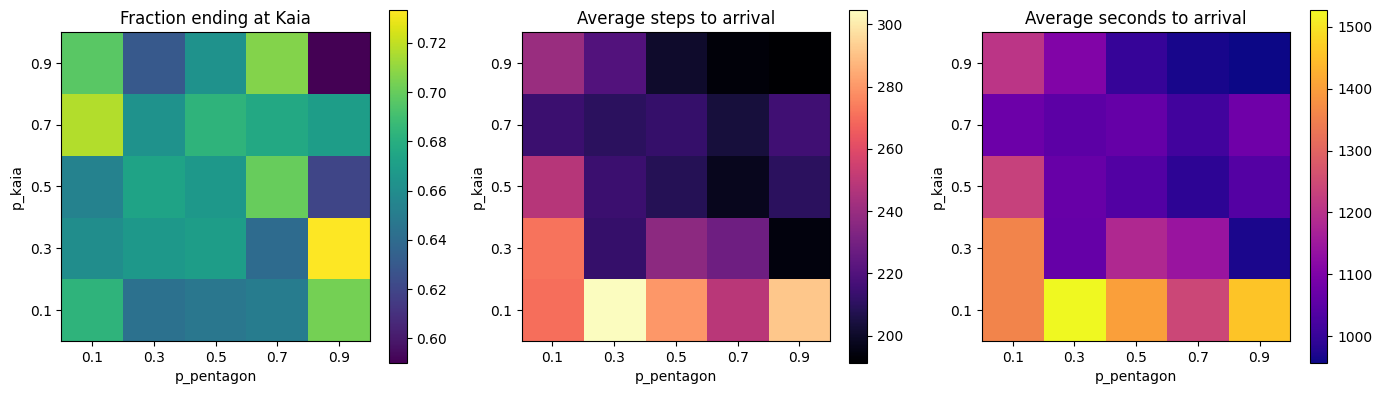

'print("Sample numeric summaries:")\nprint("Kaia fraction (rows p_kaia, cols p_pentagon):")\nprint(np.round(kaia_prob, 2))\nprint("Avg steps:")\nprint(np.round(avg_steps, 1))\nprint("Avg seconds:")\nprint(np.round(avg_seconds, 1))'

In [17]:
# Run the grid and visualize
p_vals = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
kaia_prob, avg_steps, avg_seconds = run_grid(p_vals, p_vals, n_runs=300)

def heatmap(ax, data, title, xticks, yticks, cmap="viridis"):
    im = ax.imshow(data, origin="lower", cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel("p_pentagon")
    ax.set_ylabel("p_kaia")
    ax.set_xticks(range(len(xticks)))
    ax.set_xticklabels([f"{x:.1f}" for x in xticks])
    ax.set_yticks(range(len(yticks)))
    ax.set_yticklabels([f"{y:.1f}" for y in yticks])
    cbar = plt.colorbar(im, ax=ax)
    return im, cbar

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
heatmap(axes[0], kaia_prob, "Fraction ending at Kaia", p_vals, p_vals)
heatmap(axes[1], avg_steps, "Average steps to arrival", p_vals, p_vals, cmap="magma")
heatmap(axes[2], avg_seconds, "Average seconds to arrival", p_vals, p_vals, cmap="plasma")
fig.tight_layout()
plt.show()

"""print("Sample numeric summaries:")
print("Kaia fraction (rows p_kaia, cols p_pentagon):")
print(np.round(kaia_prob, 2))
print("Avg steps:")
print(np.round(avg_steps, 1))
print("Avg seconds:")
print(np.round(avg_seconds, 1))"""

As we can see form running this cell, the chances of ending at kaia is between 62% and about 72%. These values are very close to the original average indicating that the results rely more on the actual distance, rather than the p_values. This is because Alex is twice as likely to walk over to Kaia and once there, he likely steps over Kaia multiple times Before he has a chance to move over to pentagon. The same applied for Pentagon.